In [2]:
# Cell 1: Environment Setup & Dataset Path Verification
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Dynamic file lookup for brain tumor CSV
csv_files = glob.glob('/kaggle/input/datasets/Brain Tumor.csv', recursive=True) + glob.glob('/kaggle/input/**/*.csv', recursive=True)
print("Detected Dataset CSVs:", csv_files[:2])

Detected Dataset CSVs: ['/kaggle/input/datasets/jakeshbohaju/brain-tumor/Brain Tumor.csv', '/kaggle/input/datasets/jakeshbohaju/brain-tumor/bt_dataset_t3.csv']


In [3]:
# Cell 2: Data Ingestion and Train-Test Splitting
df_bt = pd.read_csv(csv_files[0])

# Clean column names
df_bt.columns = df_bt.columns.str.strip()

# Features and Target Identification
# Drop Image identity columns if present
X = df_bt.drop(columns=['Image', 'Class'], errors='ignore')
y = df_bt['Class']

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Dataset Shape:", df_bt.shape)
print("Features List:", list(X.columns))
print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")
print("Target Balance (Class Distribution):\n", y.value_counts(normalize=True))

Dataset Shape: (3762, 15)
Features List: ['Mean', 'Variance', 'Standard Deviation', 'Entropy', 'Skewness', 'Kurtosis', 'Contrast', 'Energy', 'ASM', 'Homogeneity', 'Dissimilarity', 'Correlation', 'Coarseness']
Train Shape: (3009, 13) | Test Shape: (753, 13)
Target Balance (Class Distribution):
 Class
0    0.552632
1    0.447368
Name: proportion, dtype: float64


In [4]:
# Cell 3: XGBoost, LightGBM, CatBoost Benchmark Pipeline

# Initialize Classifier Models
models = {
    'XGBoost': xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, learning_rate=0.05, depth=6, random_seed=42, verbose=0)
}

results = []

for name, model in models.items():
    # Fit Model
    model.fit(X_train, y_train)
    
    # Predict
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    # Metrics Calculation
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

df_benchmark = pd.DataFrame(results)
print("--- Tri-Model Performance Comparison ---")
print(df_benchmark.to_string(index=False))

--- Tri-Model Performance Comparison ---
   Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
 XGBoost  0.986720    0.99696 0.973294  0.984985 0.997896
LightGBM  0.992032    1.00000 0.982196  0.991018 0.997753
CatBoost  0.990704    1.00000 0.979228  0.989505 0.998017


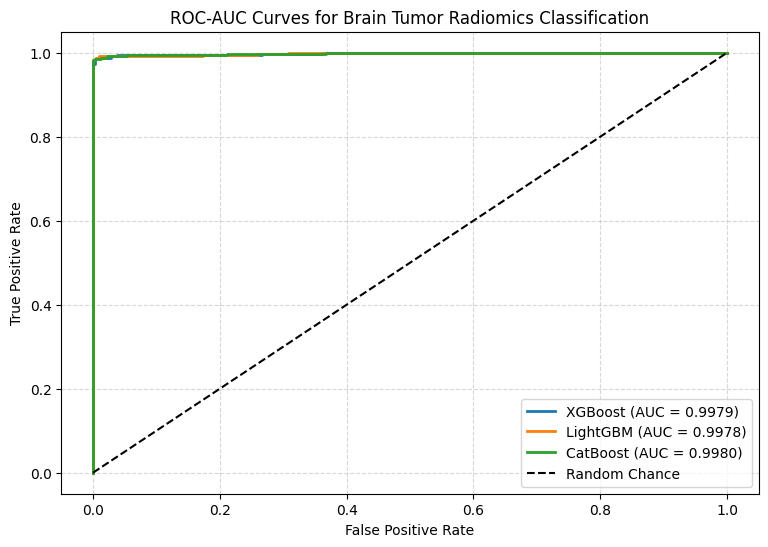

In [5]:
# Cell 4: ROC-AUC Curves Comparison Plot
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 6))

for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curves for Brain Tumor Radiomics Classification')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


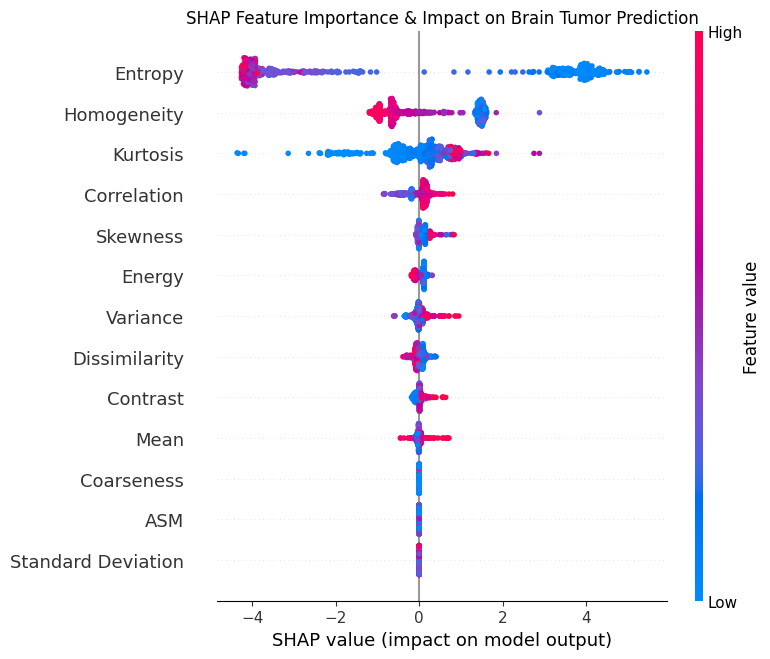

In [6]:
# Cell 5: SHAP Interpretability for Feature Impact Analysis
import shap

# Initialize SHAP Explainer on Best Model (LightGBM)
explainer = shap.TreeExplainer(models['LightGBM'])
shap_values = explainer.shap_values(X_test)

# Handle Binary Classification SHAP format
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
else:
    shap_vals_to_plot = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_plot, X_test, feature_names=X.columns, show=False)
plt.title('SHAP Feature Importance & Impact on Brain Tumor Prediction')
plt.tight_layout()
plt.show()